# Прогнозирование продаж в магазинах офлайн-ритейлера в США


В этом ноутбуке решается задача прогнозирования ежедневных продаж
для выбранного магазина и нескольких артикулов (товаров) с помощью
классических методов временных рядов:

- ARIMA,
- ETS
- SARIMA.

Цель:

- построить прогноз на горизонты **1 неделя, 1 месяц, 1 квартал**;
- сравнить качество моделей по метрикам **MAE, RMSE, MAPE**;
- выбрать наиболее удачный подход и описать его в отчёте.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from forecaster import RetailSalesForecaster

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

In [8]:
sales = pd.read_csv("../data/shop_sales.csv")
calendar = pd.read_csv("../data/shop_sales_dates.csv")
prices = pd.read_csv("../data/shop_sales_prices.csv")

sales.head()

,item_id,store_id,date_id,cnt
0,STORE_2_085,STORE_2,1,3
1,STORE_2_085,STORE_2,2,8
2,STORE_2_085,STORE_2,3,0
3,STORE_2_085,STORE_2,4,3
4,STORE_2_085,STORE_2,5,0


In [16]:
stores = list(sales["store_id"].unique())

selected_store = "STORE_2"

sales = (
    sales[sales["store_id"] == selected_store]
    .groupby("date_id", as_index=False)["cnt"]
    .sum()
    .sort_values("date_id")
)

sales["store_id"] = selected_store
sales

,date_id,cnt,store_id
0,1,1194,STORE_2
1,2,1273,STORE_2
2,3,837,STORE_2
3,4,958,STORE_2
4,5,798,STORE_2
...,...,...,...
1814,1815,1087,STORE_2
1815,1816,753,STORE_2
1816,1817,738,STORE_2
1817,1818,680,STORE_2


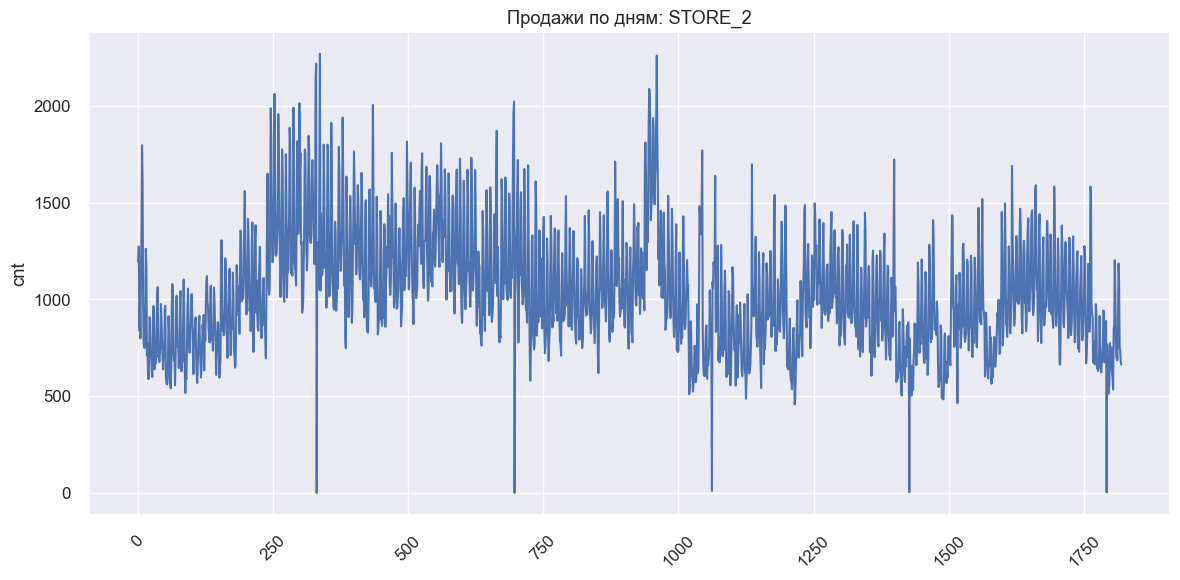

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(sales["date_id"], sales["cnt"])
plt.title(f"Продажи по дням: {selected_store}")
plt.ylabel("cnt")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Можем наблюдать, что с периодичностью примерно ~365 дней, продажи в магазине равны 0.
Это может объясняться тем, что магазин не работал в этот день из-за праздников или по иной причине.
Чтобы не искажать структуру ряда и сезонность, оставим эти дни.

Рассмотрим в разрезе нескольких недель

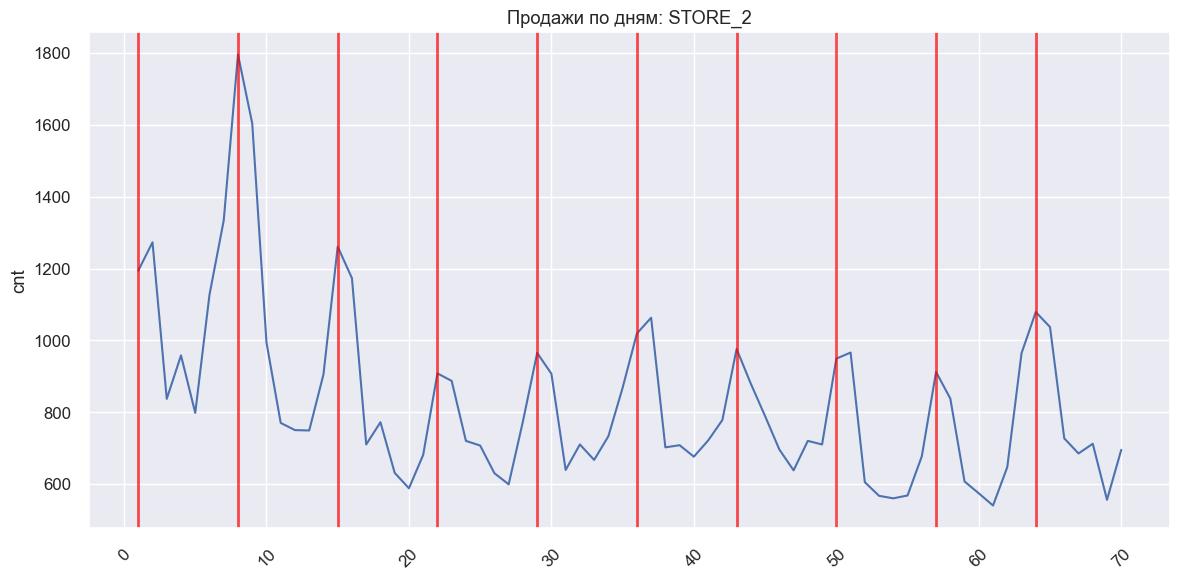

In [18]:
first_n_days = 70
tmp = sales[:first_n_days]

plt.figure(figsize=(12, 6))

# основной график
plt.plot(tmp["date_id"], tmp["cnt"], label="cnt")

# выделяем каждый 7-й день
for x in tmp["date_id"].iloc[::7]:
    plt.axvline(x=x, color="red", linewidth=2, alpha=0.7)

plt.title(f"Продажи по дням: {selected_store}")
plt.ylabel("cnt")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Визуально мы можем наблюдать недельную сезонность - пики каждый 7 дней.

# Прогнозирование

Спрогнозируем продажи с помощью реализованного нами класса

In [41]:
forecaster = RetailSalesForecaster(
    sales_df=sales,
    date_col="date_id",
    target_col="cnt",
    store_col="store_id",
    store_id=selected_store,
    freq="D",
    test_size=90,        # 90 дней ~ квартал
    seasonal_period=7,
)
forecaster.fit_all_models()

### Описание класса `RetailSalesForecaster`

`RetailSalesForecaster` — это класс для классического прогнозирования временных рядов продаж **одного магазина** (`store_id`).
Он инкапсулирует весь цикл работы с рядом: от предобработки до обучения моделей и оценки качества на разных горизонтах (неделя, месяц, квартал).

---

#### Инициализация

При создании экземпляра класс принимает:

- `sales_df` — исходный `DataFrame` с продажами;
- `date_col` — колонка с идентификатором даты (`"date_id"`);
- `target_col` — целевая переменная (`"cnt"`);
- `store_col`, `store_id` — колонка и значение идентификатора магазина;
- `freq` — частота ряда (для дневных данных `"D"`);
- `test_size` — длина тестового периода (последние N наблюдений);
- `seasonal_period` — сезонный период (для недельной сезонности `7`).

В `__post_init__` автоматически вызываются методы:
- `_prepare_series()` — подготовка временного ряда;
- `_train_test_split()` — разделение на train/test.

---

#### Предобработка данных: `_prepare_series`

Основные шаги:

1. Фильтрация по выбранному `store_id`.
2. Преобразование `date_id` из порядкового номера в календарную дату:
   ```python
   date = "2011-01-01" + (date_id - 1) дней
   ```
3. Группировка по дате и суммирование продаж.
4. Приведение к равномерной дневной частоте (`asfreq("D")`) и заполнение пропусков нулями.

Результат сохраняется в:
* `series_original_` — исходный ряд в натуральной шкале;
* `series_` — рабочая копия ряда.

---

#### Разбиение на обучающую и тестовую выборки: `_train_test_split`

* Проверяется, что `test_size` положителен и меньше длины ряда.
* Ряд делится по времени:

  * `train_` — все наблюдения до последних `test_size` точек;
  * `test_` — последние `test_size` наблюдений (будущее для модели).

Используется классическая схема **hold-out** без утечек информации.

---

#### Обучение моделей: `fit_all_models`

Метод обучает три классические модели на `train_`:

* `ARIMA` — `_fit_arima()`
  * перебирается сетка `(p, d, q)`;
  * лучшая модель выбирается по минимальному AIC;

* `ETS (Exponential Smoothing)` — `_fit_ets()`

  * аддитивный тренд и аддитивная сезонность с периодом `seasonal_period`;

* `SARIMA` — `_fit_sarima()`

  * перебирается маленькая сетка параметров `(p, d, q) × (P, D, Q, s)`;
  * выбирается модель с минимальным AIC;

---

#### Построение прогноза: `forecast(model_name, steps)`

* Принимает название модели (`"arima"`, `"ets"`, `"sarima"`) и горизонт в шагах (`steps`).
* Делает прогноз на основе уже обученной модели из `models_`.
* Создаёт будущий индекс дат с помощью `_make_future_index()`.
* Возвращает `pd.Series` с прогнозом в исходной шкале, индексированной датами.

---

#### Оценка качества: `evaluate(horizons=(7, 30, 90))`

* Строит прогноз до максимального горизонта (например, 90 дней).
* Возвращает `DataFrame` с колонками:

  ```text
  ["model", "horizon", "mae", "rmse", "mape"]
  ```

Метрики реализованы как статические методы (`_mae`, `_rmse`, `_mape`) и используются для сопоставимого сравнения качества моделей на горизонтах **неделя, месяц, квартал**.

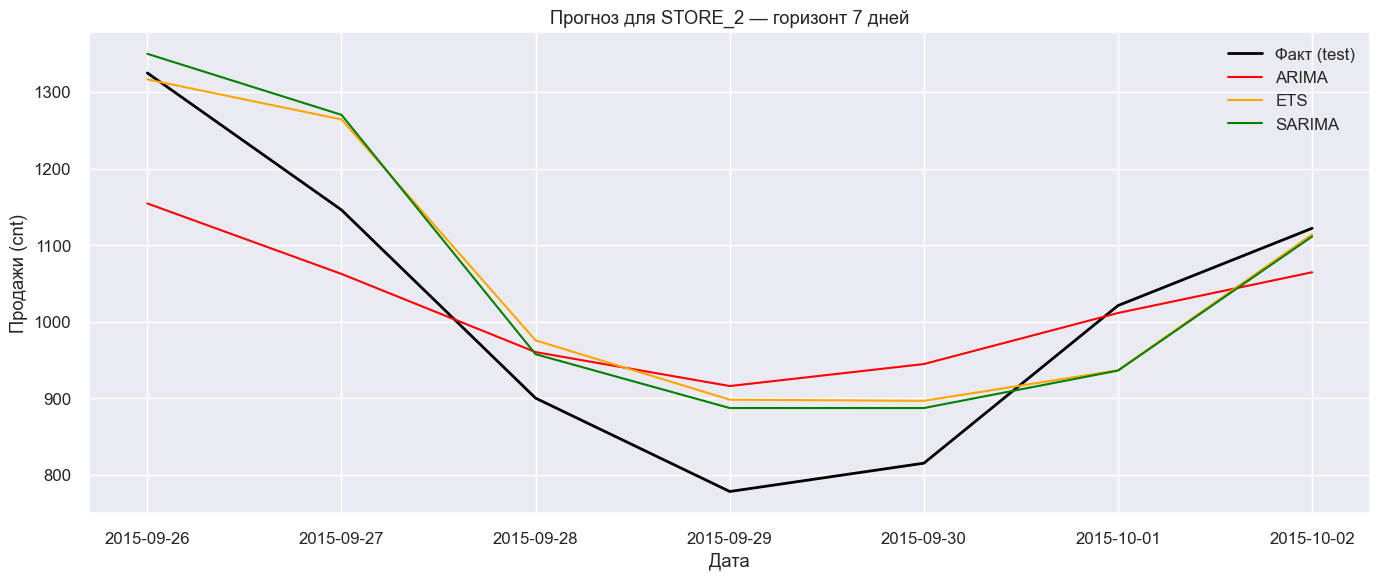

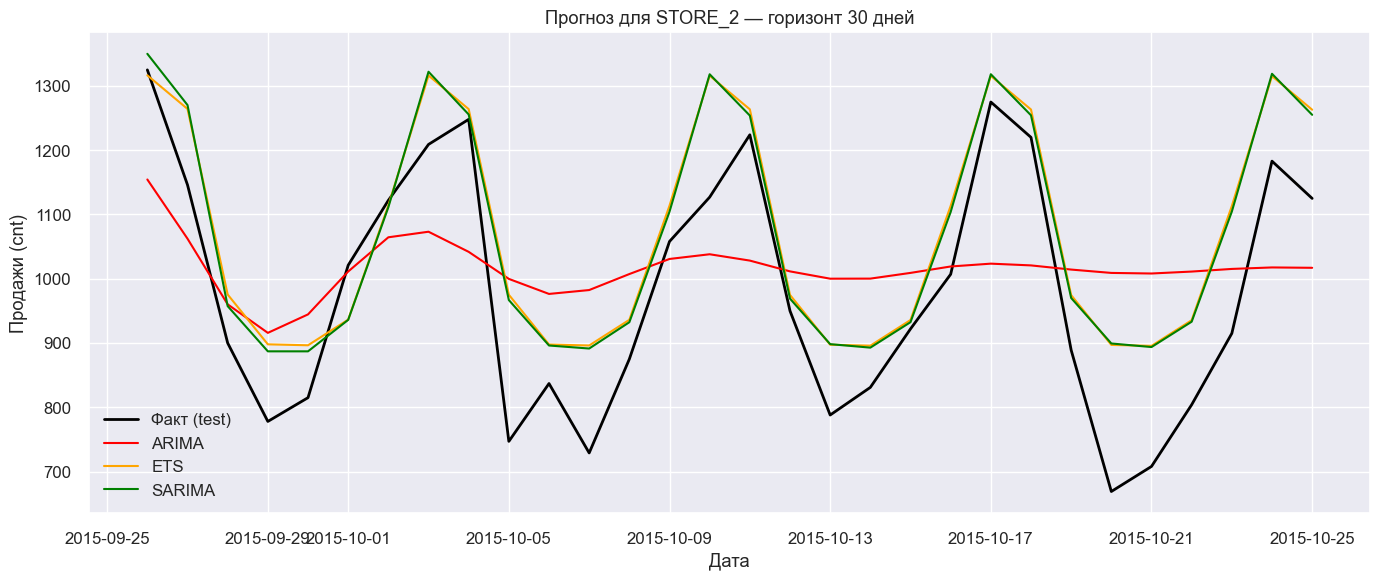

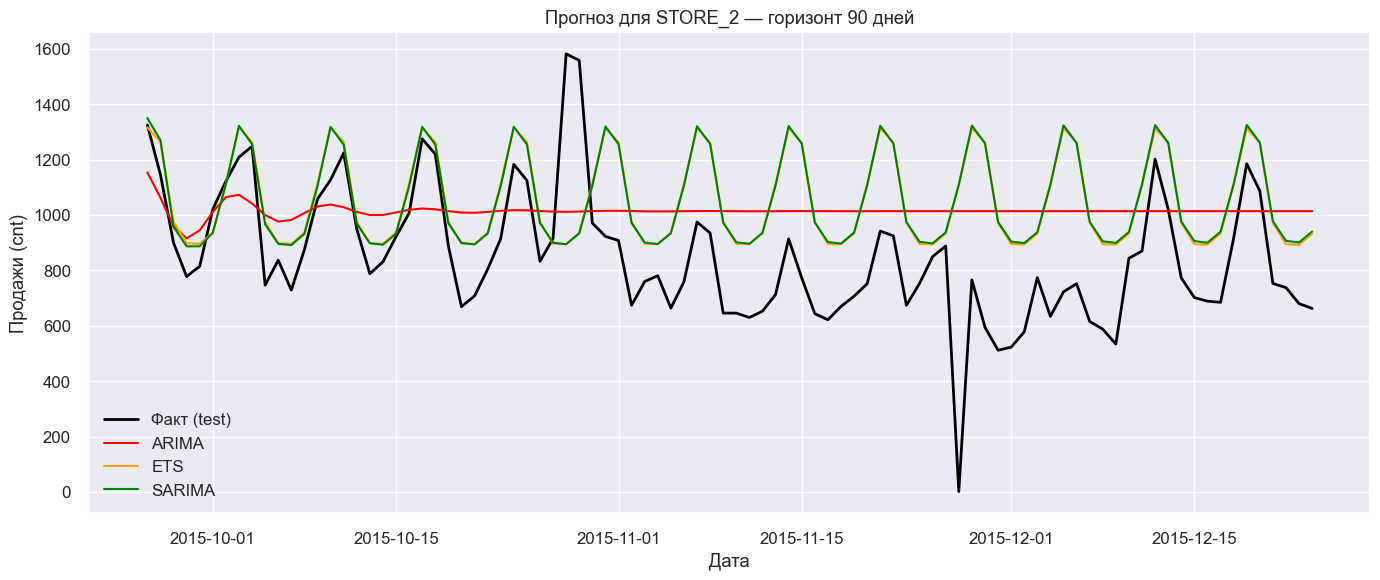

In [48]:
test = forecaster.series_original_.iloc[-forecaster.test_size:]

# Полные прогнозы на длину тестового отрезка
fc_arima_full = forecaster.forecast("arima", len(test))
fc_ets_full = forecaster.forecast("ets", len(test))
fc_sarima_full = forecaster.forecast("sarima", len(test))

horizons = [7, 30, 90]

for h in horizons:
    plt.figure(figsize=(14, 6))

    # Фактические данные для горизонта h
    plt.plot(
        test.index[:h],
        test.values[:h],
        label="Факт (test)",
        linewidth=2,
        color="black"
    )

    # Прогнозы (обрезанные до горизонта h)
    plt.plot(
        fc_arima_full.index[:h],
        fc_arima_full.values[:h],
        label="ARIMA",
        color="red"
    )
    plt.plot(
        fc_ets_full.index[:h],
        fc_ets_full.values[:h],
        label="ETS",
        color="orange"
    )
    plt.plot(
        fc_sarima_full.index[:h],
        fc_sarima_full.values[:h],
        label="SARIMA",
        color="green"
    )

    plt.title(
        f"Прогноз для {selected_store} — горизонт {h} дней"
    )
    plt.xlabel("Дата")
    plt.ylabel("Продажи (cnt)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Оценка метрик качества

In [47]:
metrics_summary = forecaster.evaluate(horizons=horizons)
print(metrics_summary)

    model  horizon         mae        rmse        mape
0   arima        7   92.712421  106.160050    9.506636
1   arima       30  147.328955  168.661840   16.307568
2   arima       90  236.889732  283.519679  592.459865
3     ets        7   70.881025   82.807930    7.679197
4     ets       30   97.504225  116.472167   11.054963
5     ets       90  236.684487  298.417694  645.778631
6  sarima        7   69.066024   79.084450    7.320805
7  sarima       30   94.279791  113.836045   10.678676
8  sarima       90  237.410662  299.509223  644.256503


В качестве метрик качества были выбраны MAE, RMSE и MAPE, так как они отражают разные типы ошибок, важные для прогнозирования спроса в розничном ритейле.

- MAE показывает среднюю абсолютную ошибку в единицах товара и удобен для понимания в контексте планирования запасов.
- RMSE позволяет оценить устойчивость модели к крупным ошибкам, которые особенно критичны в периоды всплесков спроса.
- MAPE нормирует ошибку и делает возможным корректное сравнение качества прогноза между магазинами с разным уровнем продаж.

Такой набор метрик даёт сбалансированную и интерпретируемую оценку качества моделей на недельном, месячном и квартальном горизонтах.


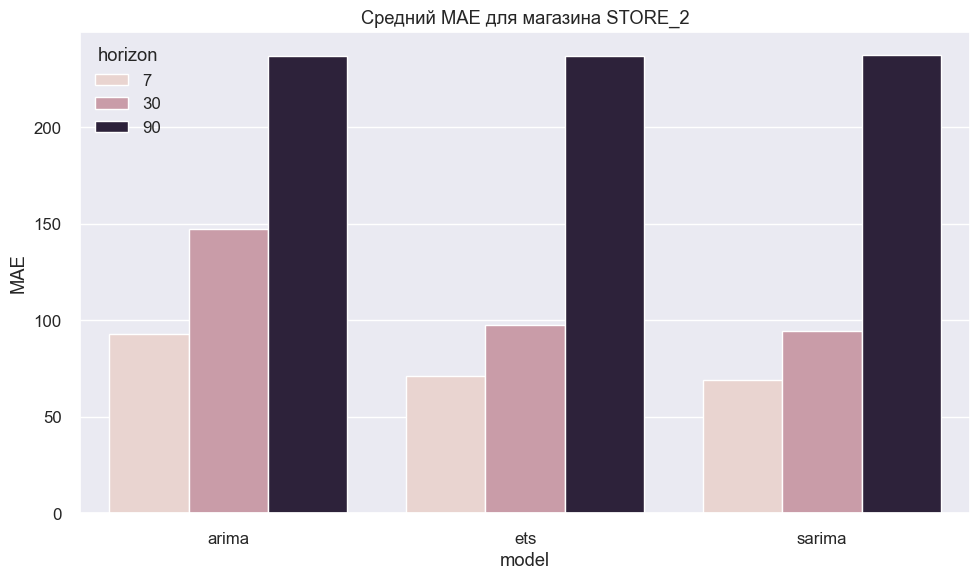

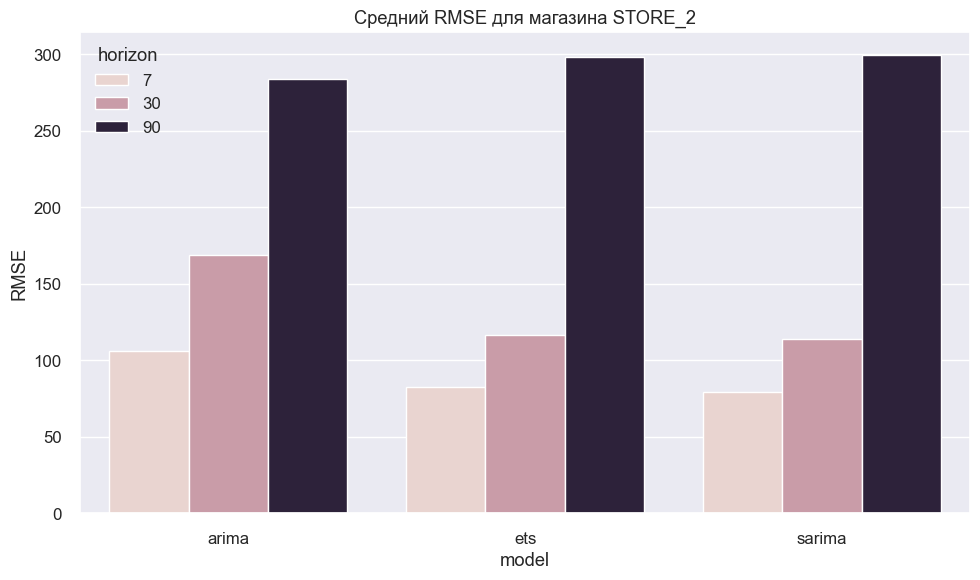

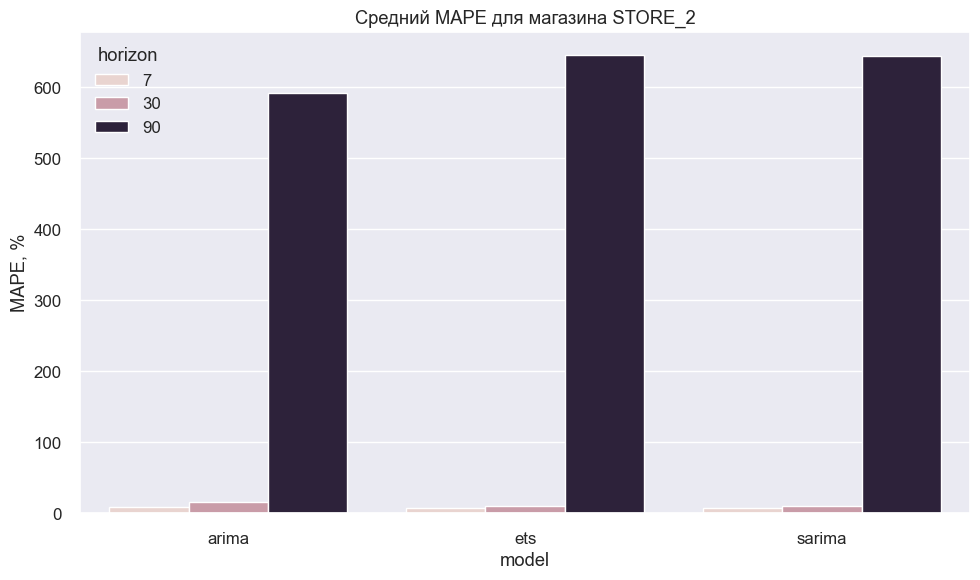

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_summary,
    x="model",
    y="mae",
    hue="horizon"
)
plt.ylabel("MAE")
plt.title(f"Средний MAE для магазина {selected_store}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_summary,
    x="model",
    y="rmse",
    hue="horizon"
)
plt.ylabel("RMSE")
plt.title(f"Средний RMSE для магазина {selected_store}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_summary,
    x="model",
    y="mape",
    hue="horizon"
)
plt.ylabel("MAPE, %")
plt.title(f"Средний MAPE для магазина {selected_store}")
plt.tight_layout()
plt.show()

## Интерпретация результатов

На недельном горизонте все модели работают неплохо.
- SARIMA показывает лучшую точность:
- ETS немного хуже, но всё ещё достаточно точна.
- ARIMA отстаёт, что логично - она плохо учитывает недельную сезонность.

На месячном горизонте:
- SARIMA снова показывает лучшую точность
- ETS почти не уступает, разница небольшая (на 3-4% хуже)

На квартальном горизонте:
- разница между моделями минимальна → сезонность становится менее важной, длинный прогноз становится более «усреднённым»
- MAPE сильно возрастает, это связано со спадом продаж в середине квартала

## Ответы на вопросы

#### 1. Какие методы предобработки данных вы использовали? Почему?

В классе `RetailSalesForecaster` выполняются следующие шаги
предобработки:

1. **Фильтрация по магазину** - оставляем только строки с выбранными `store_id`, это позволяет работать с отдельным временным рядом в разрере магахина.

2. **Агрегация по датам** - группировка данных по `date_id` и суммирую `cnt`. На случай, если в данных есть дубли по дате, получаем один агрегированный ряд.

3. **Преобразование даты и задание частоты**
   - Привожу колонку `date_id` к типу `datetime`.
   - Использую `.asfreq("D")` и заполняю пропуски нулями.
   - Такой шаг автоматически добавляет отсутствующие даты и
     гарантирует равномерную дневную сетку.


#### 2. Какие модели пробовали? Почему именно их?

В классе реализовано обучение трёх классических моделей:

1. **ARIMA**
   - Базовая модель авторегрессии с интегрированием и скользящим средним.
   - Хорошо описывает тренд и короткую память ряда.
   - Параметры `(p, d, q)` подбираются по AIC на небольшой сетке.

2. **ETS**
   - Модель экспоненциального сглаживания с трендом и сезонностью.
   - В реализации использую аддитивный тренд и аддитивную сезонность с периодом 7 дней.
   - Подходит для рядов с устойчивой недельной сезонностью.

3. **SARIMA**
   - Сезонная ARIMA с параметрами `(p, d, q) × (P, D, Q)_s`, где `s` - сезонный период (у меня `s=7`).
   - Позволяет явно моделировать недельную сезонность.
   - Параметры перебираются по небольшой сетке и выбираются по AIC.

Выбор именно этих моделей связан с тем, что:

- хорошо подходят для временных рядов продаж с ярко выраженным
  трендом и сезонностью,
- позволяют сравнить разные классы моделей:
  - чисто авторегрессионный подход (ARIMA),
  - экспоненциальное сглаживание (ETS),
  - гибрид тренда и сезонности в SARIMA.

#### 3. Проверка качества и метрики

Для оценки качества использую **hold-out** схему:

- Обучающая выборка - вся история, кроме последних 90 дней.
- Тестовая выборка - последние 90 дней (`test_size=90`).
- Модели обучаются только на train, затем строится прогноз вперёд
  на 90 дней.
- Метрики считаю на трёх горизонтах (неделя, месяц, квартал)

Используемые метрики:

1. **MAE (Mean Absolute Error)**
   $$
   MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|
   $$
   - Интерпретация: средняя абсолютная ошибка в единицах товара.
   - Удобно понимать «на сколько штук, в среднем, ошибка».

2. **RMSE (Root Mean Squared Error)**
   $$
   RMSE = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}
   $$
   - Сильнее штрафует крупные ошибки, чувствителен к выбросам.
   - Полезен, когда важно избегать больших промахов по прогнозу.

3. **MAPE (Mean Absolute Percentage Error)**
   $$
   MAPE = \frac{1}{n} \sum \frac{y_i - \hat{y}_i}{y_i} \cdot 100\%
   $$
   - Безразмерная метрика в процентах, удобно сравнивать разные
     товары друг с другом.

Выбор именно этих метрик обусловлен тем, что:

- они стандартны для задач прогнозирования спроса,
- дают понятную интерпретацию как в абсолютных (MAE, RMSE),
  так и в относительных величинах (MAPE),
- позволяют корректно сравнивать модели между собой.


#### 4. Сравнение подходов и выбор лучшей модели

В ноутбуке построена таблица `metrics_summary` и графики, где для каждой
модели (ARIMA / ETS / SARIMA) и каждого горизонта (7 / 30 / 90)
посчитаны метрики MAE, RMSE и MAPE.

Подход к выбору:

1. В качестве основной метрики качества удобно использовать **MAPE**,
   так как она:
   - легко интерпретируется (ошибка в процентах),
   - позволяет усреднять качество по товарам с разным уровнем
     продаж.

3. В качестве итоговой модели выбираю - SARIMA/ETS, они показывают одинаковые результаты, разве что SARIMA немного лучше, но значимо это не влияет на прогноз. Итоговое качес

#### 5. Какое итоговое качество модели на тестовом датасете?

Итоговое качество лучшей модели (SARIMA)

| Горизонт |  MAE   |  RMSE   |   MAPE  |
|----------| --- | --- | --- |
| 7 дней   | 69.07    |  79.08   |  7.32%   |
| 30 дней  |  94.28   |  113.84   |  10.68%   |
| 90 дней  |  ≈237   |  ≈299   |  ≈644%   |


* На длинном горизонте MAPE неинтерпретируем из-за нулевых продаж в тесте (деление на очень малые значения резко увеличивает MAPE).

- На кратком горизонте модель обеспечивает очень хорошую точность:
всего ~7% средняя процентная ошибка.

- На среднем горизонте ошибки возрастают, но остаются на приемлемом уровне (~10–11% MAPE).

- На длинном горизонте абсолютные ошибки остаются стабильными (MAE ≈ 237), что свидетельствует о том, что модель делает устойчивый долгосрочный прогноз, но MAPE становится нерелевантным из-за нулевых продаж.

